In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler #  For standardizing features (scaling).
%matplotlib inline

df = sns.load_dataset('titanic') # loads the Titanic dataset from Seaborn's built-in datasets.
print(df.head()) # prints the first few rows of the Titanic dataset.

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [ ]:
print(df.isnull().sum())  # This line prints the count of missing values for each column in the pandas DataFrame

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [ ]:
df['age'] = df['age'].fillna(df['age'].mean())

df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

# Get existing categories from the 'deck' column
existing_categories = df['deck'].cat.categories

# Add 'Unknown' to the existing categories
new_categories = existing_categories.union(['Unknown'])

# Create a new CategoricalDtype with the updated categories
new_dtype = pd.CategoricalDtype(categories=new_categories)

# Assign the new dtype to the 'deck' column and fill NaN values
df['deck'] = df['deck'].astype(new_dtype).fillna('Unknown')

print(df.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64


In [ ]:
initial_shape = df.shape
df = df.drop_duplicates()
print(initial_shape, df.shape)

(891, 15) (784, 15)


In [ ]:
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1
print(IQR)

26.05935


In [ ]:
df_no_outliers = df[(df['fare'] >= (Q1 - 1.5 * IQR)) & (df['fare'] <= (Q3 + 1.5 * IQR))]
print(df.shape, df_no_outliers.shape)

(784, 15) (682, 15)


In [ ]:
scaler = StandardScaler()
df_no_outliers[['age_scaled', 'fare_scaled']] = scaler.fit_transform(df_no_outliers[['age', 'fare']])
print(df_no_outliers[['age', 'age_scaled', 'fare', 'fare_scaled']].head())

    age  age_scaled     fare  fare_scaled
0  22.0   -0.534093   7.2500    -0.826777
1  38.0    0.645666  71.2833     3.492317
2  26.0   -0.239153   7.9250    -0.781248
3  35.0    0.424461  53.1000     2.265840
4  35.0    0.424461   8.0500    -0.772816


<ipython-input-7-09a560560ce6>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers[['age_scaled', 'fare_scaled']] = scaler.fit_transform(df_no_outliers[['age', 'fare']])
<ipython-input-7-09a560560ce6>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers[['age_scaled', 'fare_scaled']] = scaler.fit_transform(df_no_outliers[['age', 'fare']])


In [ ]:
print(df_no_outliers.describe())
print(df_no_outliers.info())

         survived      pclass         age       sibsp       parch        fare  \
count  682.000000  682.000000  682.000000  682.000000  682.000000  682.000000   
mean     0.365103    2.422287   29.243422    0.502933    0.391496   19.507490   
std      0.481812    0.766767   13.572049    1.017103    0.832940   14.836515   
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000   
25%      0.000000    2.000000   21.000000    0.000000    0.000000    7.895800   
50%      0.000000    3.000000   29.699118    0.000000    0.000000   13.000000   
75%      1.000000    3.000000   35.750000    1.000000    0.000000   26.550000   
max      1.000000    3.000000   80.000000    8.000000    6.000000   71.283300   

         age_scaled   fare_scaled  
count  6.820000e+02  6.820000e+02  
mean   5.209258e-17  1.979518e-16  
std    1.000734e+00  1.000734e+00  
min   -2.125293e+00 -1.315795e+00  
25%   -6.078280e-01 -7.832171e-01  
50%    3.360071e-02 -4.389350e-01  
75%    4.797620e-0

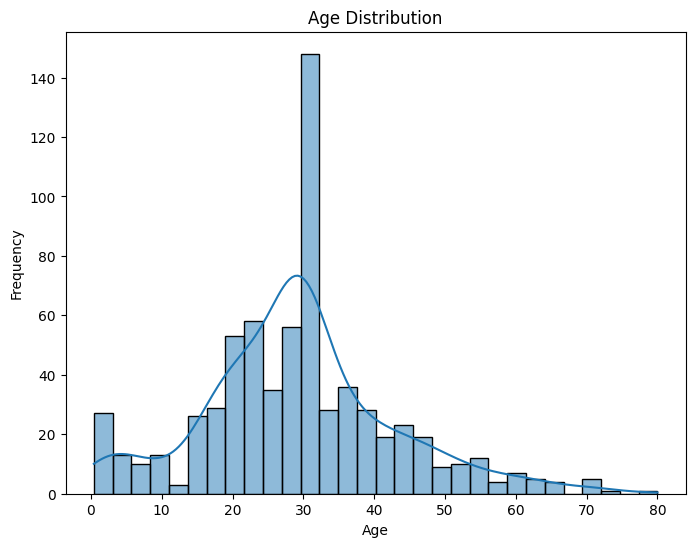

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(df_no_outliers['age'], kde=True, bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

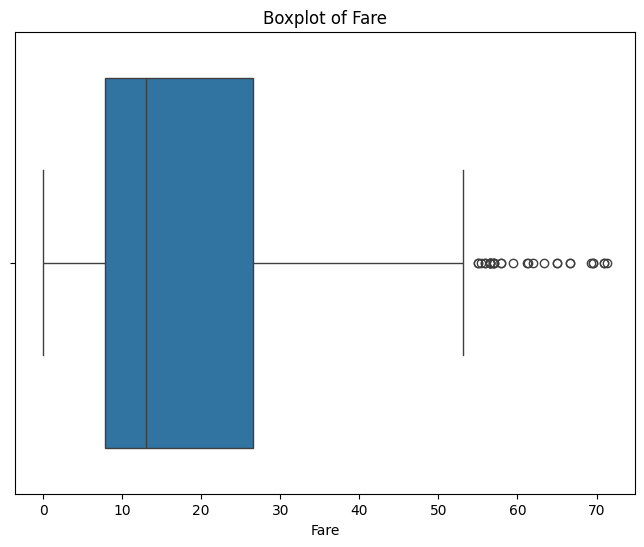

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_no_outliers['fare'])
plt.title("Boxplot of Fare")
plt.xlabel("Fare")
plt.show()

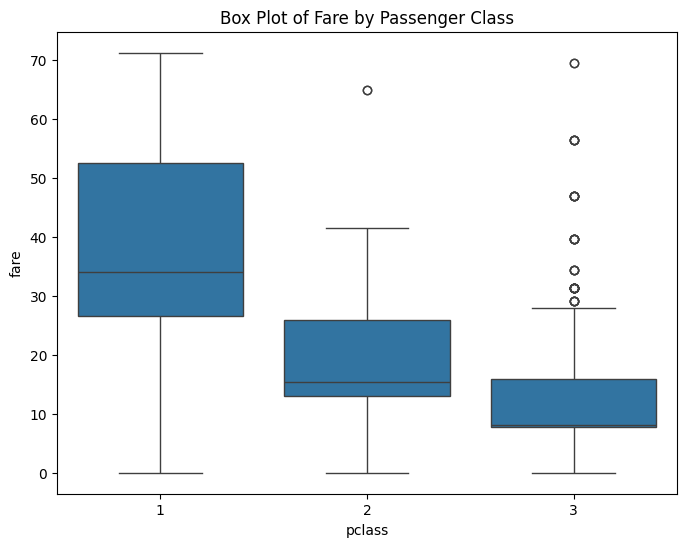

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x='pclass', y='fare', data=df_no_outliers)
plt.title("Box Plot of Fare by Passenger Class")
plt.show()

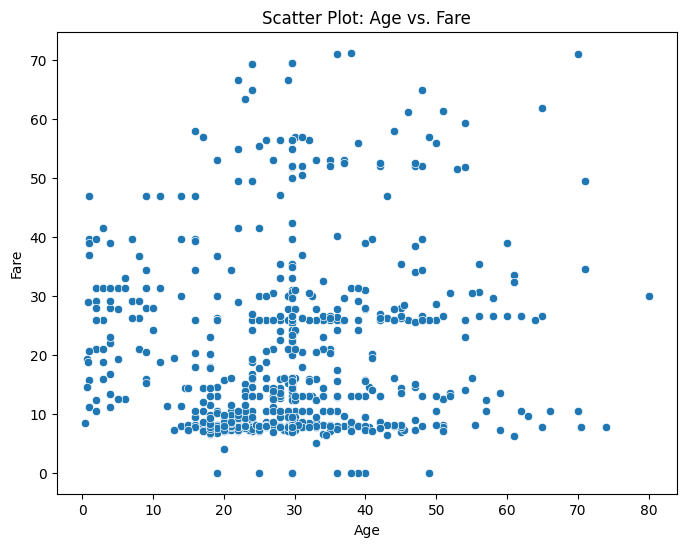

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_no_outliers['age'], y=df_no_outliers['fare'])
plt.title("Scatter Plot: Age vs. Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()


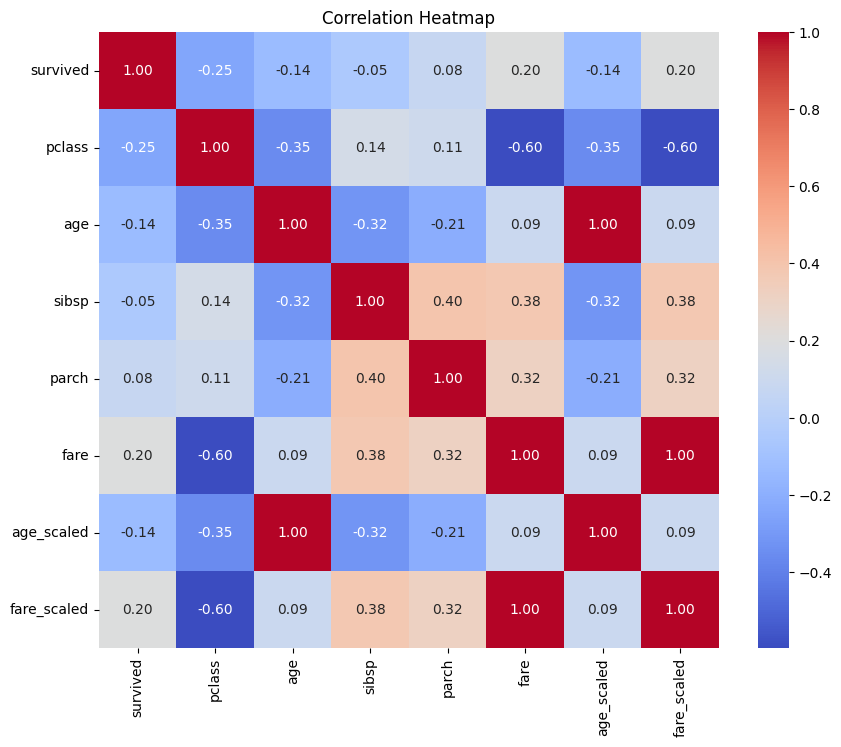

In [ ]:
plt.figure(figsize=(10, 8))
# Select only numeric features for correlation
numeric_features = df_no_outliers.select_dtypes(include=np.number)
corr = numeric_features.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

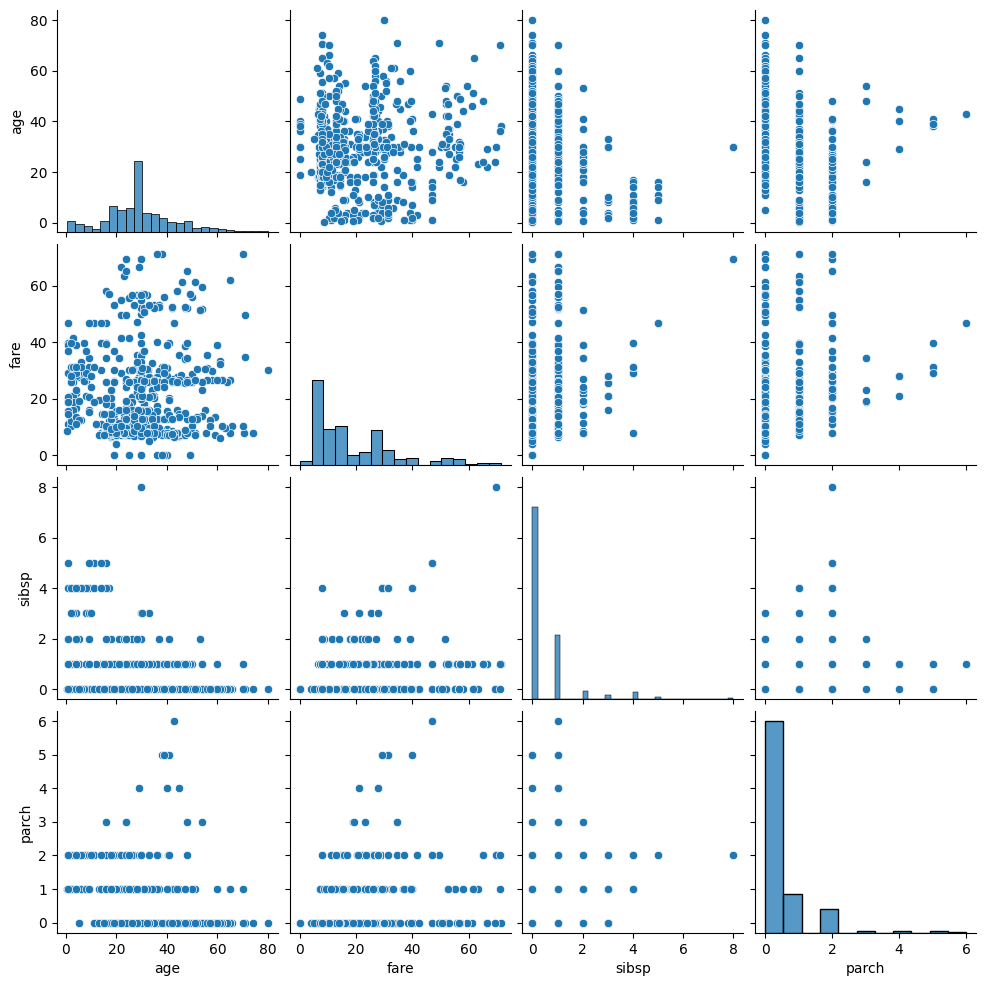

In [ ]:
sns.pairplot(df_no_outliers[['age', 'fare', 'sibsp', 'parch']])
plt.show()

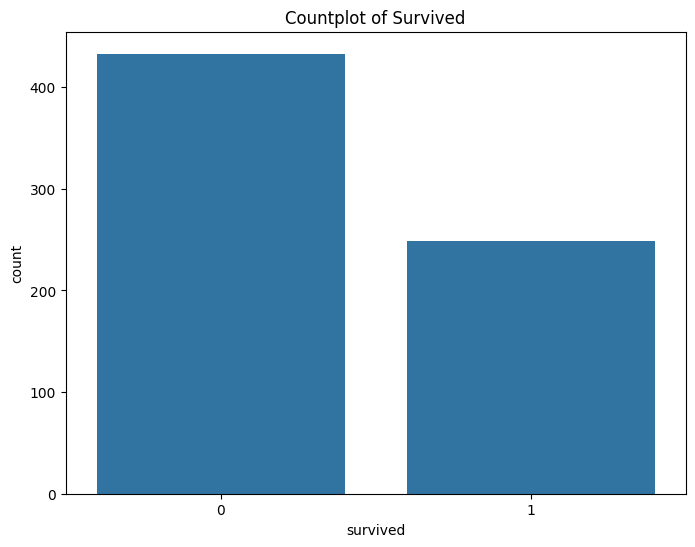

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(x='survived', data=df_no_outliers)
plt.title("Countplot of Survived")
plt.show()

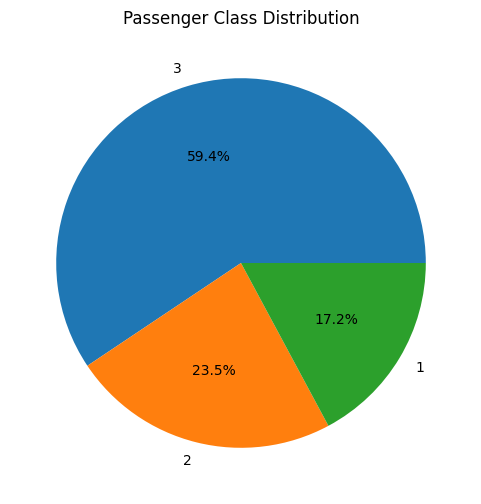

In [ ]:
plt.figure(figsize=(6,6))
df_no_outliers['pclass'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Passenger Class Distribution")
plt.ylabel('')
plt.show()

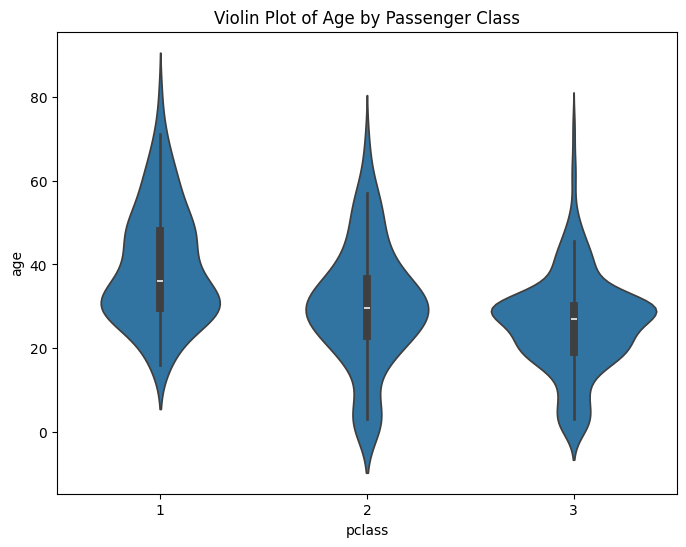

In [ ]:
plt.figure(figsize=(8,6))
sns.violinplot(x='pclass', y='age', data=df_no_outliers)
plt.title("Violin Plot of Age by Passenger Class")
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 6.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 12.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


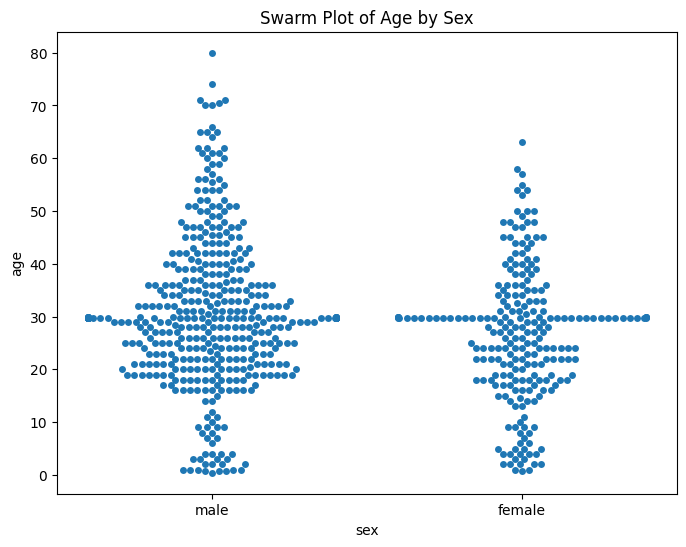

In [ ]:
plt.figure(figsize=(8,6))
sns.swarmplot(x='sex', y='age', data=df_no_outliers)
plt.title("Swarm Plot of Age by Sex")
plt.show()

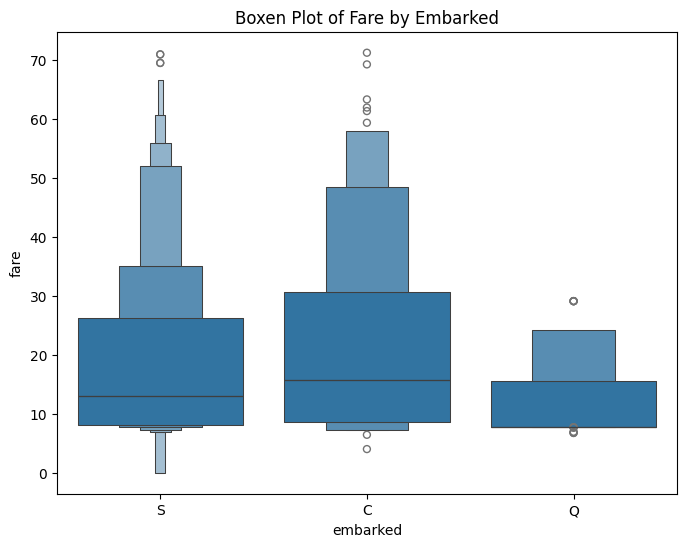

In [ ]:
plt.figure(figsize=(8,6))
sns.boxenplot(x='embarked', y='fare', data=df_no_outliers)
plt.title("Boxen Plot of Fare by Embarked")
plt.show()